In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import os

import dataset
import network
import nonlinearity

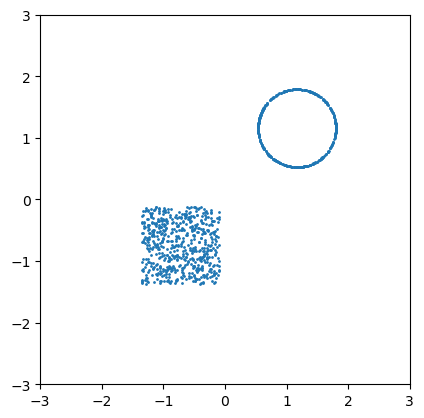

In [2]:
xs = dataset.generate_initial_datapoints(1000, normalize=True)
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(xs[:, 0], xs[:, 1], s=1)
ax.set_ylim([-3, 3])
ax.set_xlim([-3, 3])
ax.set_aspect('equal')
plt.show()

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
class Scheduler:
    def __init__(self, T):
        self.T=T
        self.betas = np.linspace(1e-4, 0.01, T)
        self.sigmas = np.sqrt(self.betas)
        self.alphas = 1 - self.betas
        self.alphabars = np.cumprod(self.alphas)

In [5]:
# Diffusion parameters
# t = 0 - circles
# t = 1 - first addition of noise
# t = 500 - all noise added, ostensibly normally distributed
T = 1000
scheduler = Scheduler(T)

# Training parameters
criterion = nn.MSELoss(reduction='mean')
npts = 100000 # npts*T is number of training samples
num_epochs = 100
opt = lambda params: torch.optim.Adam(params)
network_shape = [3, 100, 100, 100, 2]
batch_size = 64

# Plotting parameters
grid_points=400
vec_grid_points=20
hist_points = 10000
num_colors = max(network_shape)
colors = []
for i in range(num_colors):
    colors.append((np.random.uniform(0, 1), np.random.uniform(0, 1), np.random.uniform(0, 1)))
data_range = [-3, 3]

# Saving_parameters
checkpoint_path = 'checkpoints/nonlinears_{:04d}.pt'
animation_path = 'animation_sample_{}'
epochs_path = 'animation_epoch'
if not os.path.isdir(epochs_path):
    os.mkdir(epochs_path)
if not os.path.isdir('checkpoints'):
    os.mkdir('checkpoints')

In [6]:
net = network.Network(network_shape, scheduler).to(device)
optimizer = opt(net.parameters())

In [7]:
losses = []
inputs = dataset.generate_initial_datapoints(npts, normalize=True)
train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(inputs), batch_size=batch_size, shuffle=True)
full_loss = 0
alph = torch.Tensor(scheduler.alphabars)
Ts = list(range(1, T))
for i in tqdm(range(num_epochs)):
    full_loss = 0
    for inputs in train_loader:
        inputs = inputs[0]
        t = torch.randint(0, T, (inputs.shape[0],1))
        e = torch.randn_like(inputs, requires_grad=False)
        a = alph[t]
        x = torch.sqrt(a)*inputs + torch.sqrt(1-a)*e
        output = net(x.to(device), t.to(device))
        optimizer.zero_grad()
        loss = criterion(output, e.to(device))
        full_loss += loss.item()
        loss.backward()
        optimizer.step()
    losses.append(full_loss/npts)

  0%|          | 0/100 [00:00<?, ?it/s]

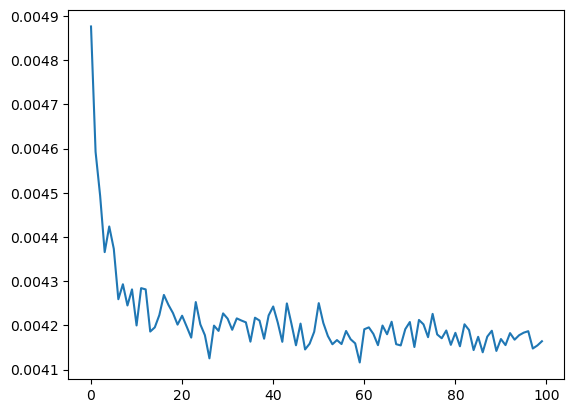

In [8]:
plt.plot(losses)

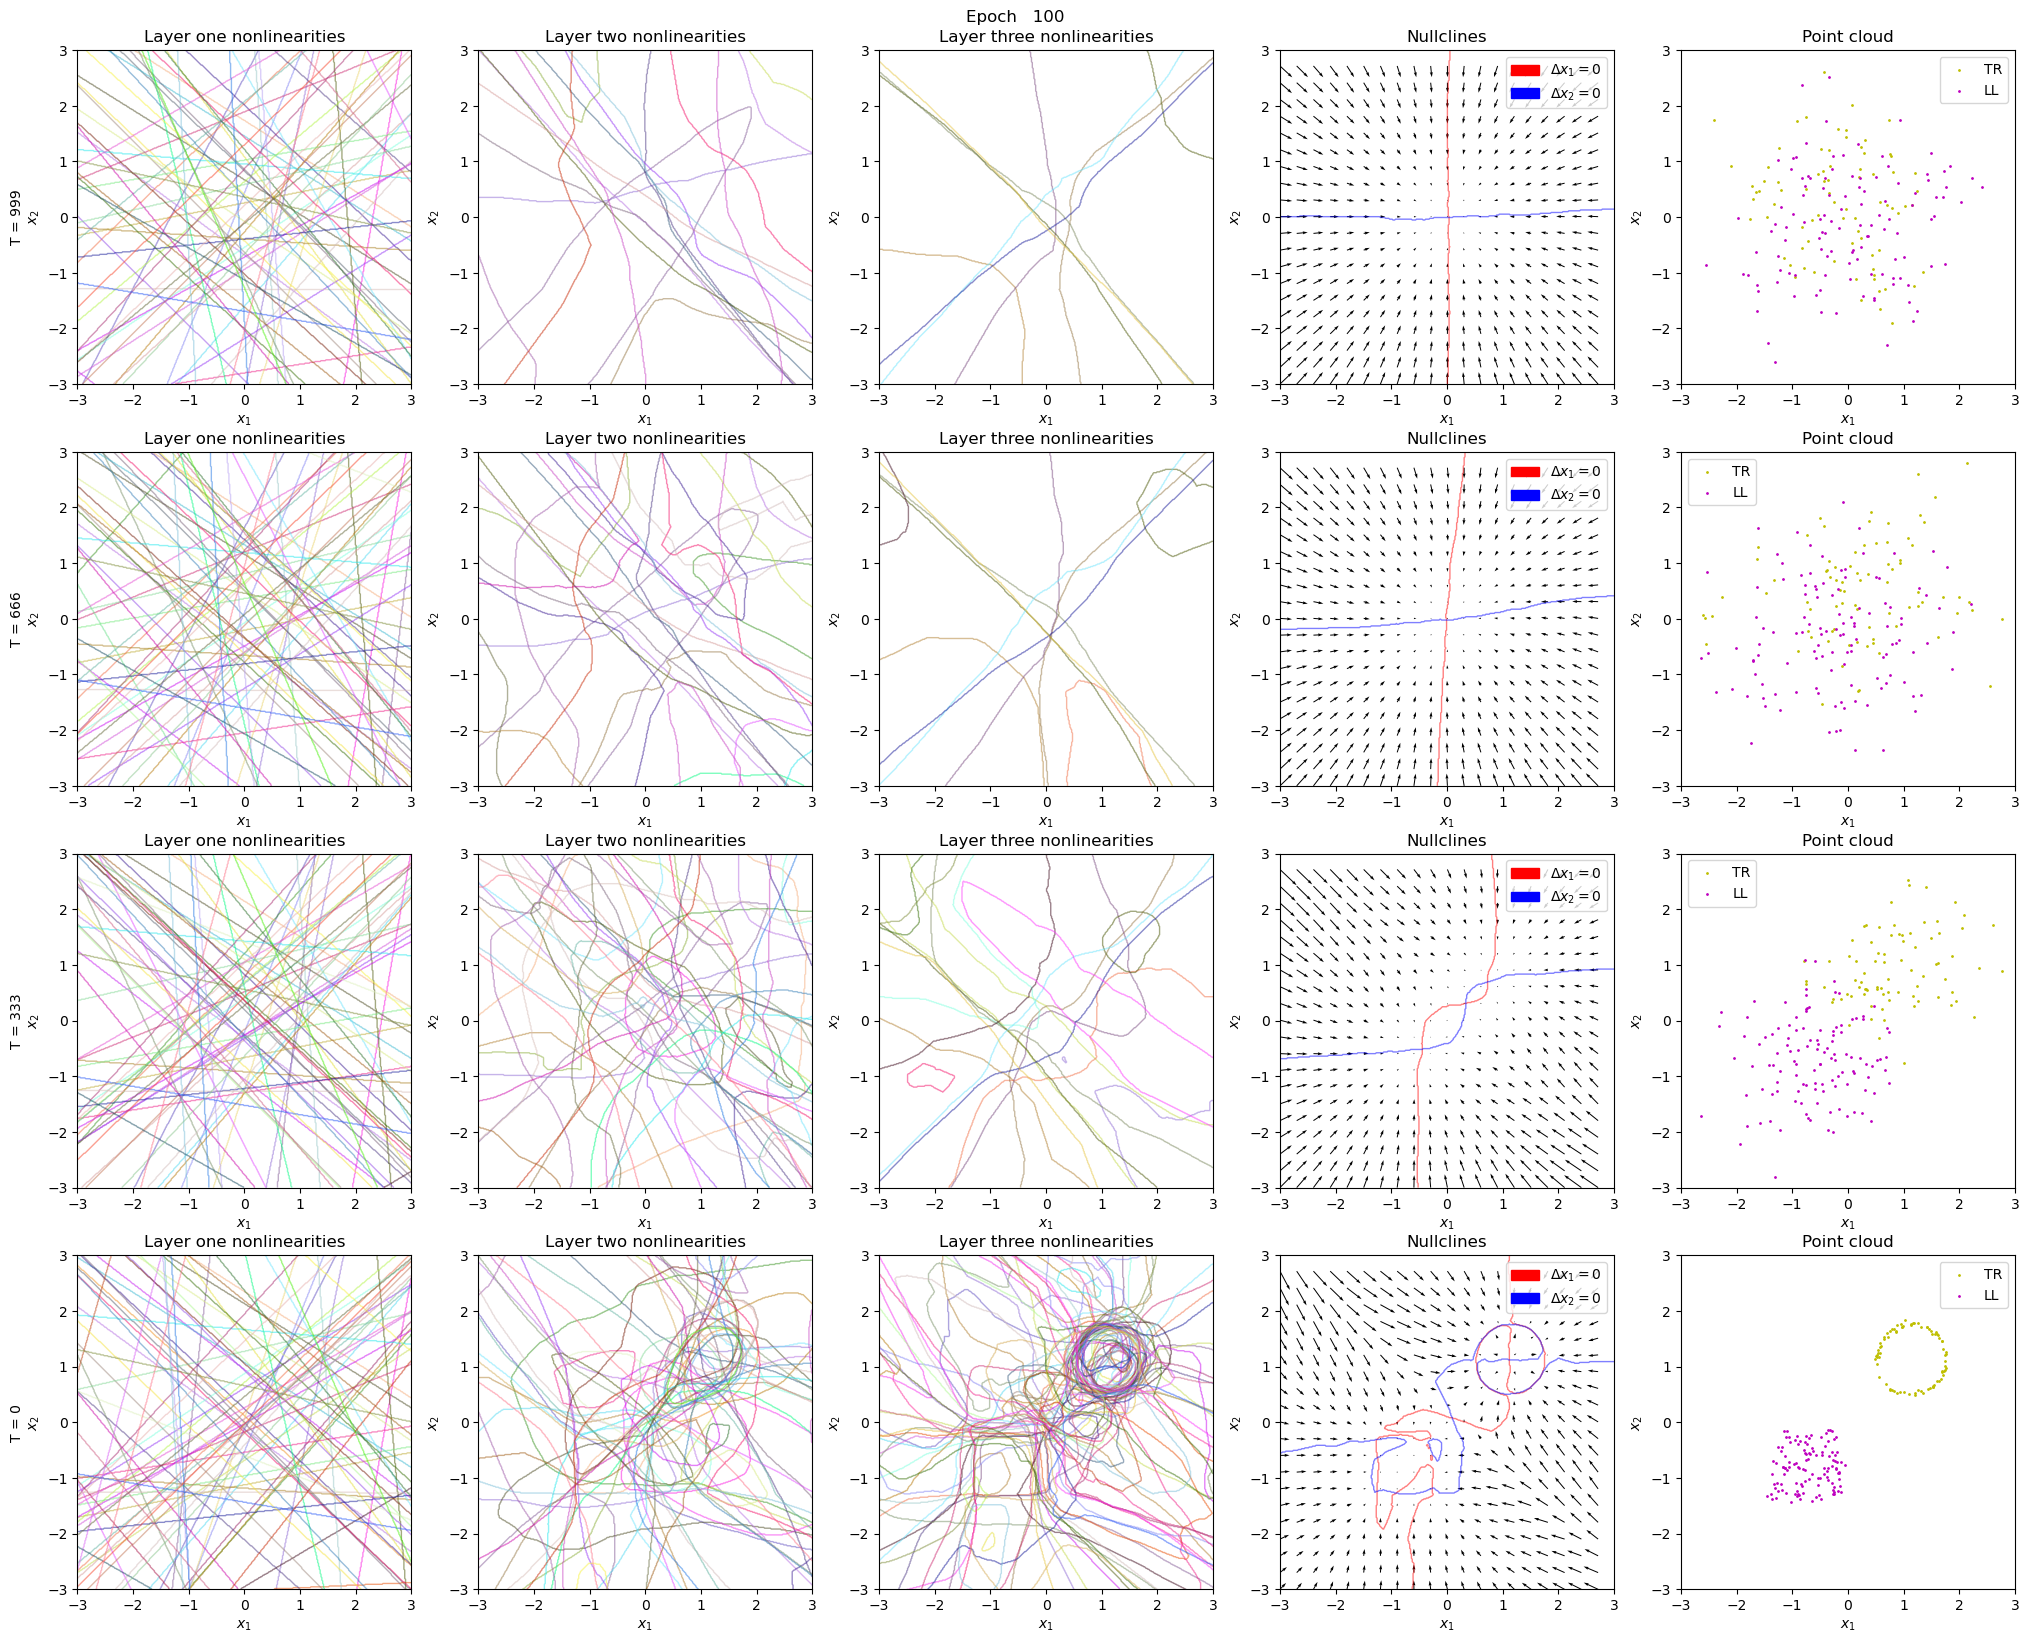

In [9]:
temp = nonlinearity.Animator(net, colors, scheduler, data_range, grid_points, vec_grid_points, hist_points, hist_points, device)
temp.draw_small(num_epochs)